# 03 — Simplified Marketing Mix Model

## Overview

This notebook compares a raw-media Ridge baseline with nine adstock-and-saturation candidates on a chronological 80/20 time-based validation window. The same window is used for parameter selection, so it is not an independent test set. The notebook saves the selected model, metadata, validation predictions, directional estimated contributions, and proxy ROI outputs for later budget scenarios.

## Context & Methods

Run Notebooks 01 and 02 first. The model combines seven transformed media channels with competitor spend, holiday, promotion, linear trend, and annual Fourier controls. `StandardScaler` and Ridge regression are fitted within a pipeline on the training period only.

### Key Assumptions

- The first 80% of observed-sales weeks is training data; the final 20% is a chronological time-based validation window. The same window is used to select transformation parameters, so it is not an independent test set.
- Candidate adstock decay and saturation half-point settings use the small deterministic grid defined in `src.modeling`.
- Contribution is estimated by zeroing one raw channel and rescoring; negative estimates are retained.
- All contribution and proxy ROI outputs are directional, synthetic-data-based diagnostics—not causal or production-grade estimates.

### 1. Set Up the Project Path

In [1]:
from pathlib import Path
import sys

working_directory = Path.cwd().resolve()
PROJECT_ROOT = (
    working_directory.parent
    if working_directory.name.lower() == "notebooks"
    else working_directory
)
if not (PROJECT_ROOT / "src").is_dir():
    raise RuntimeError(
        "Launch this notebook from the project root or the notebooks directory."
    )
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f"Project root: {PROJECT_ROOT}")

Project root: C:\yifei\Workspace\marketing-mmm-python\.worktrees\mmm-implementation


In [2]:
import json

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

from src.config import get_project_paths
from src.data_prep import MEDIA_COLUMNS
from src.modeling import (
    add_control_features,
    chronological_split,
    estimate_channel_contributions,
    fit_candidate_models,
)
from src.transformations import (
    geometric_adstock,
    hill_saturation,
    transform_media,
)
from src.visualization import (
    plot_actual_vs_predicted,
    plot_channel_contributions,
    plot_proxy_roi,
)

paths = get_project_paths(PROJECT_ROOT)
paths.charts.mkdir(parents=True, exist_ok=True)
paths.reports.mkdir(parents=True, exist_ok=True)
paths.model.mkdir(parents=True, exist_ok=True)

## Data

### 2. Load the Modelling Table

In [3]:
modelling_path = paths.processed / "modelling_ready_data.csv"
channel_summary_path = paths.reports / "channel_summary.csv"
if not modelling_path.exists() or not channel_summary_path.exists():
    raise FileNotFoundError("Run Notebooks 01 and 02 before this notebook.")

modelling_data = pd.read_csv(modelling_path, parse_dates=["date"])
channel_summary = pd.read_csv(channel_summary_path)
observed_data = modelling_data.dropna(subset=["sales"]).sort_values("date").reset_index(drop=True)

print(f"Rows available: {len(modelling_data):,}")
print(f"Observed sales rows used for fitting: {len(observed_data):,}")
display(observed_data[["date", "sales", *MEDIA_COLUMNS]].head(5))

Rows available: 209
Observed sales rows used for fitting: 206


,date,sales,instagram_spend,google_ads_spend,tv_spend,youtube_spend,newspaper_spend,influencer_spend,ott_spend
0,2022-01-03,1084031.0,54880.0,0.0,47580.0,57190.0,0.0,34610.0,0.0
1,2022-01-10,1225796.0,67170.0,0.0,60140.0,64150.0,0.0,18000.0,0.0
2,2022-01-17,1445628.0,90520.0,0.0,52180.0,30710.0,0.0,48300.0,0.0
3,2022-01-24,1445965.0,77800.0,0.0,41940.0,39610.0,0.0,49160.0,0.0
4,2022-01-31,1370267.0,87050.0,0.0,29720.0,23430.0,0.0,34790.0,0.0


### 3. Illustrate the Public Media Transformation

In [4]:
transformation_example, example_half_points = transform_media(
    observed_data.head(12), MEDIA_COLUMNS, decay=0.5, half_point_multiplier=1.0
)
display(transformation_example[["date", *MEDIA_COLUMNS]].head(3).round(4))
display(pd.Series(example_half_points, name="example_half_point").to_frame().round(2))

,date,instagram_spend,google_ads_spend,tv_spend,youtube_spend,newspaper_spend,influencer_spend,ott_spend
0,2022-01-03,0.2902,0.0,0.3471,0.3771,0.0,0.4859,0.0
1,2022-01-10,0.4134,0.0,0.4839,0.4954,0.0,0.4909,0.0
2,2022-01-17,0.5066,0.0,0.5126,0.4493,0.0,0.6430,0.0


,example_half_point
instagram_spend,134234.84
google_ads_spend,141058.12
tv_spend,89500.41
youtube_spend,94483.91
newspaper_spend,8860.00
influencer_spend,36617.03
ott_spend,92500.00


## Results

### 4. Fit and Compare Baseline and Candidate Models

In [5]:
model_comparison, model_bundle = fit_candidate_models(
    modelling_data, MEDIA_COLUMNS
)
model_comparison = model_comparison.sort_values(
    ["rmse", "mae"], kind="stable"
).reset_index(drop=True)

In [6]:
model_comparison.to_csv(paths.reports / "model_comparison.csv", index=False)

In [7]:
display(model_comparison.round(4))

,model_type,decay,half_point_multiplier,rmse,mae,r2
0,transformed_ridge,0.5,0.5,100985.3841,79424.6730,0.9408
1,transformed_ridge,0.5,1.0,112043.6874,82632.3871,0.9271
2,transformed_ridge,0.5,1.5,124957.7503,93855.3432,0.9093
3,transformed_ridge,0.2,0.5,197127.6213,159773.3885,0.7744
4,transformed_ridge,0.2,1.0,201530.9995,159789.3847,0.7642
5,transformed_ridge,0.2,1.5,205645.3822,162526.5252,0.7545
6,baseline_ridge,NaN,NaN,277454.3293,227161.8837,0.5531
7,transformed_ridge,0.8,0.5,422246.8589,356478.9905,-0.0351
8,transformed_ridge,0.8,1.0,445716.6765,377957.1746,-0.1534
9,transformed_ridge,0.8,1.5,464100.1226,391878.6397,-0.2505


In [8]:
selected_row = model_comparison.loc[
    (model_comparison["model_type"] == "transformed_ridge")
    & np.isclose(model_comparison["decay"], model_bundle.decay)
    & np.isclose(
        model_comparison["half_point_multiplier"],
        model_bundle.half_point_multiplier,
    )
].iloc[0]
baseline_row = model_comparison.loc[
    model_comparison["model_type"] == "baseline_ridge"
].iloc[0]
rmse_change_pct = (
    (baseline_row["rmse"] - selected_row["rmse"]) / baseline_row["rmse"] * 100.0
)
display(Markdown(
    f"**Finding.** The selected transformed candidate uses decay **{model_bundle.decay:.1f}** "
    f"and half-point multiplier **{model_bundle.half_point_multiplier:.1f}**, with validation-window "
    f"RMSE **{selected_row['rmse']:,.1f}** (a **{rmse_change_pct:.1f}% reduction** versus the raw baseline). "
    "**Business meaning.** Carryover and diminishing-return transformations improve the "
    "directional specification only if validation error falls. **Caution.** This same window "
    "selects the candidate parameters and is not an independent test set; it does not establish "
    "causal validity or generalisation to future campaigns."
))

**Finding.** The selected transformed candidate uses decay **0.5** and half-point multiplier **0.5**, with validation-window RMSE **100,985.4** (a **63.6% reduction** versus the raw baseline). **Business meaning.** Carryover and diminishing-return transformations improve the directional specification only if validation error falls. **Caution.** This same window selects the candidate parameters and is not an independent test set; it does not establish causal validity or generalisation to future campaigns.

### 5. Recreate Time-Based Validation Predictions

In [9]:
train_data, validation_data = chronological_split(observed_data, test_fraction=0.20)
controlled_data, _ = add_control_features(
    modelling_data,
    date_origin=model_bundle.feature_date_origin,
    competitor_fallback=model_bundle.competitor_fallback,
)
transformed_data = controlled_data.copy()
for channel in model_bundle.media_columns:
    channel_adstock = geometric_adstock(
        transformed_data[channel].to_numpy(dtype=float), model_bundle.decay
    )
    transformed_data[channel] = hill_saturation(
        channel_adstock, model_bundle.half_points[channel]
    )

validation_mask = transformed_data["date"].isin(validation_data["date"])
validation_features = transformed_data.loc[validation_mask]
predictions = model_bundle.pipeline.predict(
    validation_features[model_bundle.feature_names].to_numpy(dtype=float)
)
validation_predictions = pd.DataFrame(
    {
        "date": validation_features["date"].to_numpy(),
        "actual": validation_features["sales"].to_numpy(),
        "predicted": predictions,
    }
)
validation_predictions["residual"] = (
    validation_predictions["actual"] - validation_predictions["predicted"]
)
assert len(validation_predictions) == len(validation_data)
assert validation_predictions["date"].min() > model_bundle.training_cutoff

validation_predictions.to_csv(
    paths.reports / "model_validation_predictions.csv", index=False
)
display(validation_predictions.head(8).round(2))

,date,actual,predicted,residual
0,2025-03-17,2565427.0,2485990.70,79436.30
1,2025-03-24,2616604.0,2628094.92,-11490.92
2,2025-03-31,2563774.0,2467152.52,96621.48
3,2025-04-07,2309863.0,2333504.68,-23641.68
4,2025-04-14,2180514.0,2195663.73,-15149.73
5,2025-04-21,2058161.0,2022389.30,35771.70
6,2025-04-28,1906430.0,1862593.81,43836.19
7,2025-05-05,2603953.0,2423642.09,180310.91


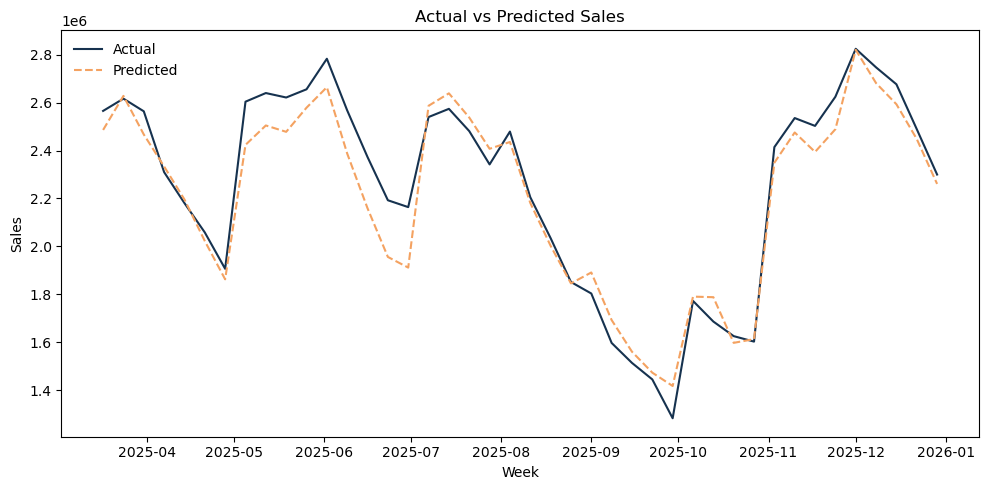

In [10]:
axes = plot_actual_vs_predicted(
    validation_predictions, paths.charts / "actual_vs_predicted_sales.png"
)
plt.show()
plt.close(axes.figure)

### 6. Estimate Directional Contribution and Proxy ROI

In [11]:
contribution_roi = estimate_channel_contributions(
    model_bundle, modelling_data
).sort_values("estimated_contribution", ascending=False).reset_index(drop=True)

In [12]:
contribution_roi.to_csv(
    paths.reports / "channel_contribution_roi.csv", index=False
)

In [13]:
channel_summary = channel_summary.drop(
    columns=["estimated_contribution", "contribution_share", "proxy_roi"],
    errors="ignore",
).merge(
    contribution_roi[
        ["channel", "estimated_contribution", "contribution_share", "proxy_roi"]
    ],
    on="channel",
    how="left",
    validate="one_to_one",
)

In [14]:
channel_summary.to_csv(channel_summary_path, index=False)

In [15]:
display(contribution_roi.round(4))

,channel,estimated_contribution,contribution_share,spend,proxy_roi
0,instagram_spend,1.412942e+08,0.2633,11440220.0,12.3507
1,google_ads_spend,1.219860e+08,0.2273,12024860.0,10.1445
2,ott_spend,7.801168e+07,0.1454,9180190.0,8.4978
3,influencer_spend,6.456087e+07,0.1203,4706220.0,13.7182
4,tv_spend,5.869413e+07,0.1094,7870450.0,7.4575
5,newspaper_spend,3.700233e+07,0.0690,1069650.0,34.5929
6,youtube_spend,3.504551e+07,0.0653,5989090.0,5.8516


In [16]:
leading_contribution = contribution_roi.iloc[0]
leading_roi = contribution_roi.sort_values("proxy_roi", ascending=False).iloc[0]
display(Markdown(
    f"**Finding.** **{leading_contribution['channel'].replace('_', ' ').title()}** has the "
    f"largest estimated contribution ({leading_contribution['estimated_contribution']:,.0f}), "
    f"while **{leading_roi['channel'].replace('_', ' ').title()}** has the highest proxy ROI "
    f"({leading_roi['proxy_roi']:.3f}). **Business meaning.** These rankings can frame "
    "scenario exploration. **Caution.** They are directional outputs from synthetic data, "
    "not causal return estimates or budget recommendations."
))

**Finding.** **Instagram Spend** has the largest estimated contribution (141,294,239), while **Newspaper Spend** has the highest proxy ROI (34.593). **Business meaning.** These rankings can frame scenario exploration. **Caution.** They are directional outputs from synthetic data, not causal return estimates or budget recommendations.

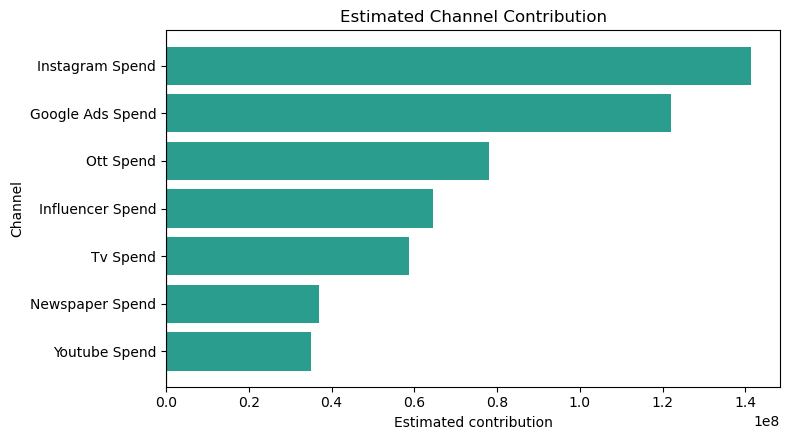

In [17]:
axes = plot_channel_contributions(
    contribution_roi, paths.charts / "estimated_channel_contribution.png"
)
plt.show()
plt.close(axes.figure)

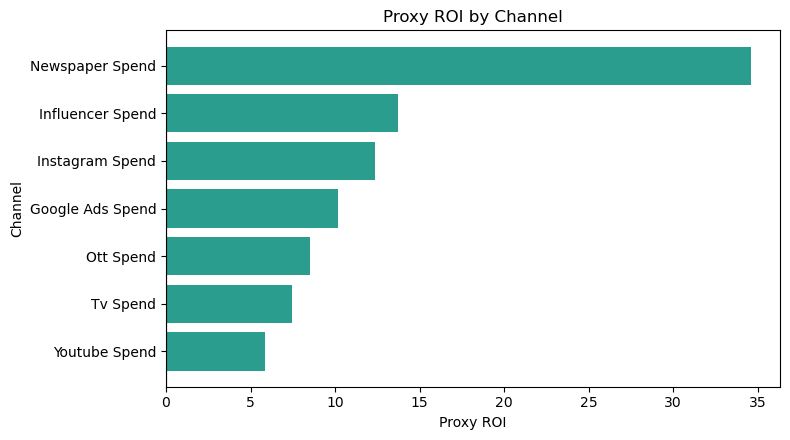

In [18]:
axes = plot_proxy_roi(
    contribution_roi, paths.charts / "proxy_roi_by_channel.png"
)
plt.show()
plt.close(axes.figure)

### 7. Save the Model Bundle and Metadata

In [19]:
bundle_path = paths.model / "model_bundle.joblib"
metadata_path = paths.model / "model_metadata.json"
joblib.dump(model_bundle, bundle_path)

model_metadata = {
    "model_type": "directional_transformed_ridge_mmm",
    "data_basis": "synthetic portfolio dataset",
    "causal_claim": False,
    "training_cutoff": model_bundle.training_cutoff.date().isoformat(),
    "validation_window_start": pd.Timestamp(validation_predictions["date"].min()).date().isoformat(),
    "observed_rows": int(len(observed_data)),
    "training_rows": int(len(train_data)),
    "validation_window_rows": int(len(validation_data)),
    "ridge_alpha": 1.0,
    "decay": float(model_bundle.decay),
    "half_point_multiplier": float(model_bundle.half_point_multiplier),
    "half_points": {key: float(value) for key, value in model_bundle.half_points.items()},
    "media_columns": list(model_bundle.media_columns),
    "feature_names": list(model_bundle.feature_names),
    "validation_window_metrics": {
        "rmse": float(selected_row["rmse"]),
        "mae": float(selected_row["mae"]),
        "r2": float(selected_row["r2"]),
    },
    "directional_caveat": (
        "Educational synthetic-data model; contribution and proxy ROI are not causal estimates."
    ),
}
metadata_path.write_text(
    json.dumps(model_metadata, indent=2), encoding="utf-8"
)

print(f"Saved {bundle_path.relative_to(PROJECT_ROOT)}")
print(f"Saved {metadata_path.relative_to(PROJECT_ROOT)}")

Saved output\model\model_bundle.joblib
Saved output\model\model_metadata.json


## Takeaways

- Chronological validation keeps the final observed weeks outside model fitting, but the same window selects candidate parameters and is not an independent test set.
- The selected transformed Ridge model and its exact parameters are saved for reproducible scenario scoring.
- Estimated contribution and proxy ROI are directional diagnostics from synthetic data. They should be triangulated with experiments, uncertainty analysis, and business context before any real allocation decision.